# Connessione al db

In [33]:
import pandas as pd
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 144 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_24452\989049557.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,...,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,...,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,...,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


In [34]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [35]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df['ansia_totale'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)
df["resilienza"] = (df["coping"] - df["ansia_totale"])
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)
df["gap"] = df["Item_8"] - df["coping"]

features = [
    "ansia_totale",
    "coping",
    "evitamento",
    "resilienza",
    "gap"
]

X = df[features].dropna()

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df.loc[X.index, "cluster"] = clusters

In [38]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df["cluster"] = range(4)

print(centroids_df)

   ansia_totale    coping  evitamento  resilienza       gap  cluster
0      2.876822  3.311224    2.301020    0.434402 -0.698980        0
1      1.968629  3.729730    1.436937    1.761100 -2.054054        1
2      4.326488  1.975000    4.104167   -2.351488  2.125000        2
3      3.257993  2.428571    2.800000   -0.829422  0.285714        3


In [39]:
def assegna_nome_cluster(row):
    ansia = row["ansia_totale"]
    coping = row["coping"]
    evitamento = row["evitamento"]
    gap = row["gap"]
    autoeff = row["resilienza"]
    
    if ansia > 0.6 and coping < 0.4 and gap > 0.2:
        return "Ansiosi Disfunzionali"
    
    elif ansia > 0.6 and coping >= 0.5 and gap <= 0.2:
        return "Ansiosi Funzionali"
    
    elif ansia < 0.4 and coping >= 0.6 and autoeff >= 0.6:
        return "Resilienti"
    
    elif evitamento > 0.6 and coping < 0.5:
        return "Evitanti"
    
    else:
        return "Intermedio"

In [40]:
centroids_df["nome_cluster"] = centroids_df.apply(assegna_nome_cluster, axis=1)

In [41]:
cluster_map = centroids_df.set_index("cluster")["nome_cluster"].to_dict()

df["cluster_nome"] = df["cluster"].map(cluster_map)

In [42]:
print(df[["cluster", "cluster_nome"]].head())

# distribuzione
print(df["cluster_nome"].value_counts())

# medie per cluster
print(df.groupby("cluster_nome")[features].mean())

   cluster        cluster_nome
0      2.0          Intermedio
1      0.0  Ansiosi Funzionali
2      3.0          Intermedio
3      0.0  Ansiosi Funzionali
4      0.0  Ansiosi Funzionali
cluster_nome
Ansiosi Funzionali    86
Intermedio            55
Name: count, dtype: int64
                    ansia_totale    coping  evitamento  resilienza       gap
cluster_nome                                                                
Ansiosi Funzionali      2.486088  3.491279    1.929264    1.005191 -1.281977
Intermedio              3.646537  2.263636    3.274242   -1.382900  0.954545


In [43]:
df[["cluster", "cluster_nome"]]

,cluster,cluster_nome
0,2.0,Intermedio
1,0.0,Ansiosi Funzionali
2,3.0,Intermedio
3,0.0,Ansiosi Funzionali
4,0.0,Ansiosi Funzionali
...,...,...
139,3.0,Intermedio
140,0.0,Ansiosi Funzionali
141,0.0,Ansiosi Funzionali
142,3.0,Intermedio


In [44]:
df["cluster_nome"].value_counts()

cluster_nome
Ansiosi Funzionali    86
Intermedio            55
Name: count, dtype: int64

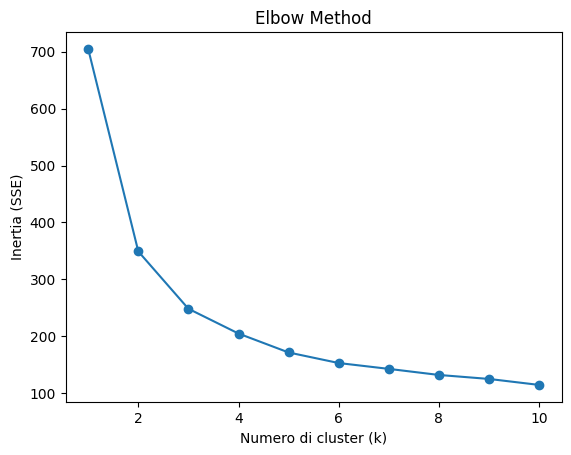

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

In [46]:
import numpy as np

def trova_elbow(K, inertia):
    # punti iniziale e finale
    p1 = np.array([K[0], inertia[0]])
    p2 = np.array([K[-1], inertia[-1]])
    
    distanze = []
    
    for i in range(len(K)):
        p = np.array([K[i], inertia[i]])
        
        # distanza punto-linea
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distanze.append(dist)
    
    return K[np.argmax(distanze)]

In [47]:
k_ottimale = trova_elbow(list(K_range), inertia)
print(f"Numero ottimale di cluster: {k_ottimale}")

Numero ottimale di cluster: 3


C:\Users\Utente\AppData\Local\Temp\ipykernel_24452\337219889.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


In [48]:
kmeans = KMeans(n_clusters=k_ottimale, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [49]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1, cmap="viridis", edgecolor='k', alpha=1, marker='o', linewidth=0.5, label='Dati')
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

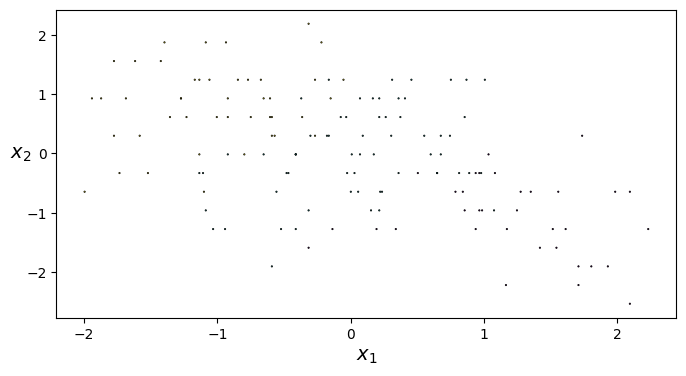

In [50]:
plt.figure(figsize=(8, 4))
plot_clusters(X_scaled, clusters)
plt.show()

In [51]:
from sklearn.metrics import silhouette_score

results = []

K_range = range(2, 11)  # silhouette non è definito per k=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil_score
    })

In [52]:
results_df = pd.DataFrame(results)

# ordina per silhouette (migliore in alto)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

print(results_df)

    k     inertia  silhouette_score
0   2  348.900609          0.406970
1   3  248.112201          0.315914
3   5  171.253371          0.289662
2   4  204.533906          0.274394
4   6  152.674181          0.267259
6   8  131.715981          0.259394
5   7  142.394371          0.246806
8  10  114.192314          0.224335
7   9  124.698755          0.223862


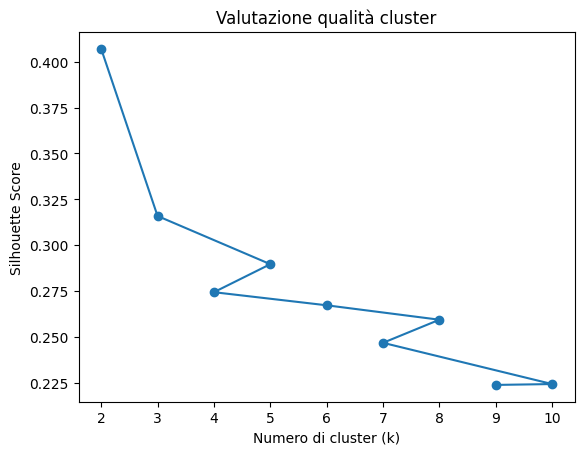

In [53]:
plt.figure()
plt.plot(results_df["k"], results_df["silhouette_score"], marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Valutazione qualità cluster")
plt.show()

In [54]:
best_k = results_df.iloc[0]["k"]
print(f"Miglior numero di cluster (Silhouette): {best_k}")

Miglior numero di cluster (Silhouette): 2.0
